In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import warnings
warnings.filterwarnings('ignore') 

import dunestyle.matplotlib as dunestyle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


DUNE plot style enabled


1.81796464295501 1.8132253632186148
0.13035080359207285 0.14779175755815732
0.07812764438803521 4.936049245649812


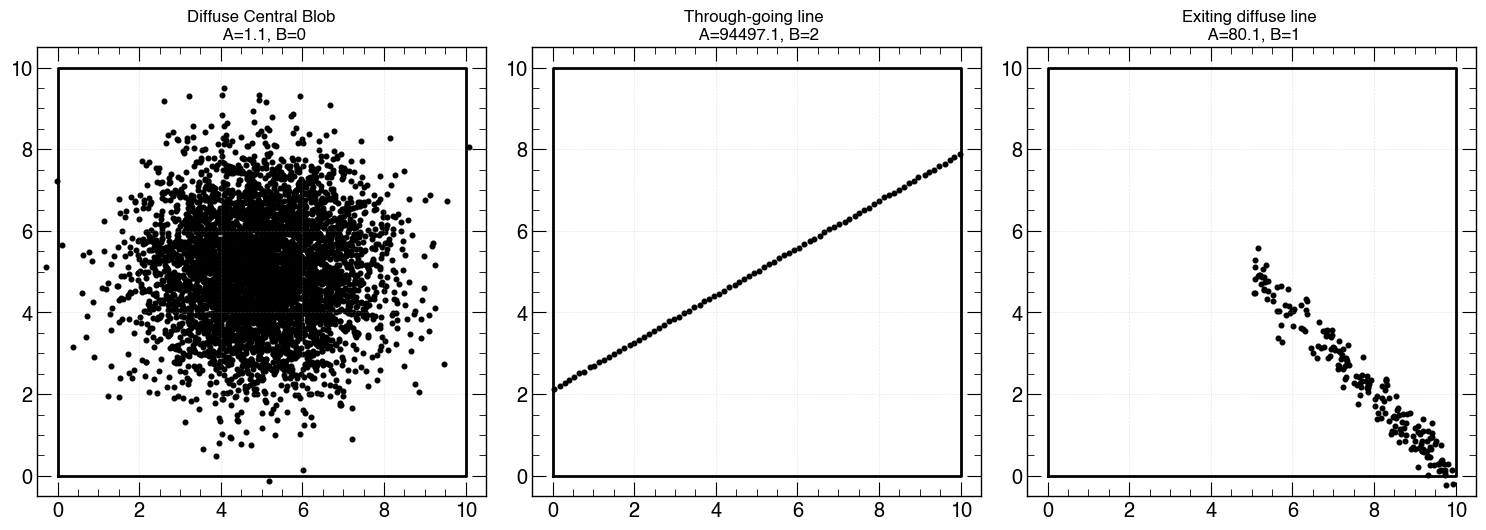


--- Scores ---
Central blob     :  anisotropy=1.06, boundary=0
Full crossing    :  anisotropy=94497.11, boundary=2
Partial line     :  anisotropy=80.08, boundary=1


In [2]:

np.random.seed(42)

box_size = 10
center = np.array([5, 5])

def score_track(x, y, box_size=10):
    pts = np.column_stack([x, y])

    # centroid
    mu = pts.mean(axis=0)

    # covariance (PCA)
    C = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(C)

    # sort eigenvalues descending
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    # anisotropy (line-likeness)
    A = vals[0] / (vals[1] + 1e-12)

    # project onto principal axis
    u = vecs[:, 0]
    s = (pts - mu) @ u

    s01, s99 = np.percentile(s, [1,99])
    
    # endpoints in original space
    #p_min = mu + s.min() * u
    #p_max = mu + s.max() * u
    p_min = mu + s01*u
    p_max = mu + s99*u

    def wall_dist(p):
        x, y = p
        return min(x, box_size - x, y, box_size - y)

    d1 = wall_dist(p_min)
    d2 = wall_dist(p_max)
    print(d1,d2)

    # boundary contact score
    tau = 0.5
    B = int(d1 < tau) + int(d2 < tau)

    return A, B



fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scenario 1: Central blob 
n1 = 5000
theta = np.pi / 4
length = 1.0

t = np.random.uniform(-length/2, length/2, n1)

x1 = center[0] + t*np.cos(theta) + np.random.normal(0, 1.35, n1)
y1 = center[1] + t*np.sin(theta) + np.random.normal(0, 1.35, n1)

A1, B1 = score_track(x1, y1, box_size)

axes[0].scatter(x1, y1, s=8)
axes[0].set_title(f"Diffuse Central Blob\n A={A1:.1f}, B={B1}", fontsize=12)


# Scenario 2: Full crossing line
n2 = 100
theta = np.pi / 6

t = np.linspace(-7, 7, n2)

x2 = center[0] + t*np.cos(theta) + np.random.normal(0, 0.01, n2)
y2 = center[1] + t*np.sin(theta) + np.random.normal(0, 0.01, n2)

mask = (x2 >= 0) & (x2 <= box_size) & (y2 >= 0) & (y2 <= box_size)

A2, B2 = score_track(x2[mask], y2[mask], box_size)

axes[1].scatter(x2[mask], y2[mask], s=8)
axes[1].set_title(f"Through-going line \n A={A2:.1f}, B={B2}", fontsize=12)


# Scenario 3: Partial line
n3 = 200
theta = -np.pi / 4

t = np.random.uniform(0, 7, n3)

x3 = center[0] + t*np.cos(theta) + np.random.normal(0, 0.01, n3)
y3 = center[1] + t*np.sin(theta) + np.random.normal(0, 0.3, n3) 

A3, B3 = score_track(x3, y3, box_size)

axes[2].scatter(x3, y3, s=8)
axes[2].set_title(f"Exiting diffuse line \n A={A3:.1f}, B={B3}", fontsize=12)


#PLOT 
box_x = [0, box_size, box_size, 0, 0]
box_y = [0, 0, box_size, box_size, 0]

for ax in axes:
    ax.plot(box_x, box_y, 'k-', lw=2)
    ax.set_xlim(-0.5, box_size + 0.5)
    ax.set_ylim(-0.5, box_size + 0.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- Scores ---")
print(f"Central blob     :  anisotropy={A1:.2f}, boundary={B1}")
print(f"Full crossing    :  anisotropy={A2:.2f}, boundary={B2}")
print(f"Partial line     :  anisotropy={A3:.2f}, boundary={B3}")

# Load actual beam and cosmic data

In [16]:
tps= pd.read_pickle("./trig_data/cosmics/cosmic_tps_13k_view2_1.pkl")
nutps = pd.read_pickle("./../fd-hd-benchmark-trigger/trigger_data/beam_chunks/nue_TPs_cbgd_12.pkl")
numutps = pd.read_pickle("./../fd-hd-benchmark-trigger/trigger_data/beam_chunks/numu_TPs_cbgd_12.pkl")

#tps= pd.read_pickle("./trig_data/cosmics/cosmic_tps_13k_view2_3.pkl")
#nutps = pd.read_pickle("./../fd-hd-benchmark-trigger/trigger_data/beam_chunks/nue_TPs_cbgd_11.pkl")
  

# Anisotropy score

In [ ]:
def get_anisotropy_3d(df, sigma_cut=3.0):
    df = df[df.bt_edep > 0]
    if len(df) < 20:
        return np.nan

    pts = np.column_stack([df.bt_x.values, df.bt_y.values, df.bt_z.values])
    w = df.bt_edep.values / df.bt_edep.sum()

    # First-pass PCA
    mu = np.average(pts, weights=w, axis=0)
    pts_c = pts - mu
    C = (pts_c * w[:, None]).T @ pts_c
    vals, vecs = np.linalg.eigh(C) # evalues, evectors 
    # sort descending
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]

    # Project onto the two minor axes (transverse plane)
    minor_vecs = vecs[:, 1:]                      # shape (3, 2)
    transverse_proj = pts_c @ minor_vecs          # shape (N, 2)
    transverse_dist = np.linalg.norm(transverse_proj, axis=1)
    trans_std = np.sqrt(np.average(transverse_dist**2, weights=w))

    mask = transverse_dist < sigma_cut * trans_std
    if mask.sum() < 3:
        return np.nan

    # Second-pass PCA on cleaned points
    pts2 = pts[mask]
    w2 = df.bt_edep.values[mask] / df.bt_edep.values[mask].sum()
    mu2 = np.average(pts2, weights=w2, axis=0)
    pts2_c = pts2 - mu2
    C2 = (pts2_c * w2[:, None]).T @ pts2_c
    vals2, _ = np.linalg.eigh(C2)
    vals2 = np.sort(vals2)[::-1]                  # λ0 ≥ λ1 ≥ λ2

    return vals2[0] / (vals2[1] + 1e-12)




cosmic_anisotropy_scores_3d = tps.groupby("event_uid").apply(get_anisotropy_3d)
beam_anisotropy_scores_3d = nutps.groupby("event_uid").apply(get_anisotropy_3d)
beamnumu_anisotropy_scores_3d = numutps.groupby("event_uid").apply(get_anisotropy_3d)

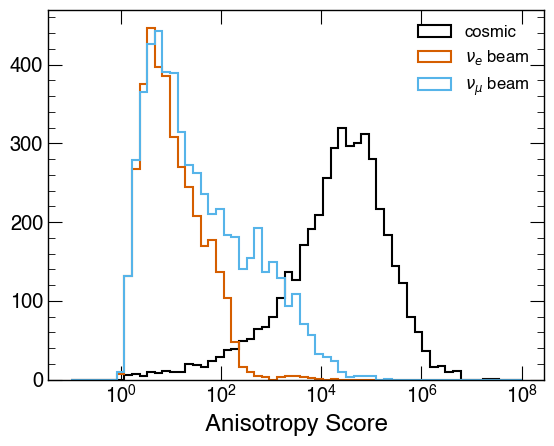

In [19]:

bins = np.logspace(-1,8, 60)
plt.hist(cosmic_anisotropy_scores_3d,bins=bins, histtype='step', label = 'cosmic' )
plt.hist(beam_anisotropy_scores_3d, bins =bins, histtype='step' , label = r'$\nu_e$ beam')
plt.hist(beamnumu_anisotropy_scores_3d, bins =bins, histtype='step' , label = r'$\nu_{\mu}$ beam')

plt.legend()
plt.xscale('log')
plt.xlabel("Anisotropy Score")
plt.show()


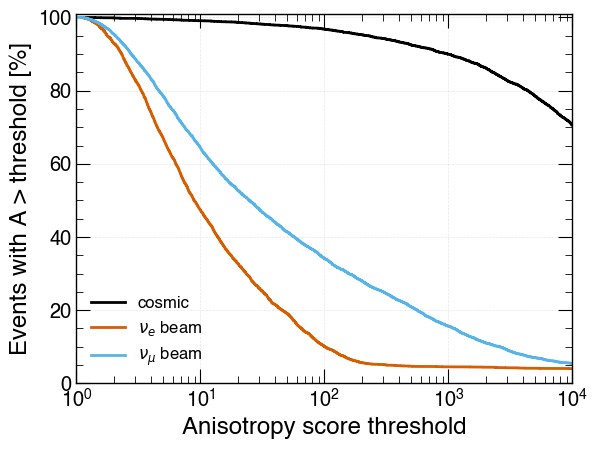

In [20]:

bins = np.logspace(-1, 8, 100)

for scores, label in [(cosmic_anisotropy_scores_3d, "cosmic"), (beam_anisotropy_scores_3d, r"$\nu_e$ beam"), (beamnumu_anisotropy_scores_3d, r"$\nu_{\mu}$ beam")]:
    scores = np.sort(scores)
    frac = 1 - np.arange(len(scores)) / len(scores)
    plt.step(scores, 100*frac, where="post", label=label)

plt.xscale("log")
plt.xlabel("Anisotropy score threshold")
plt.ylabel("Events with A > threshold [%]")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(1,1e4)
plt.ylim(0,101)
plt.show()

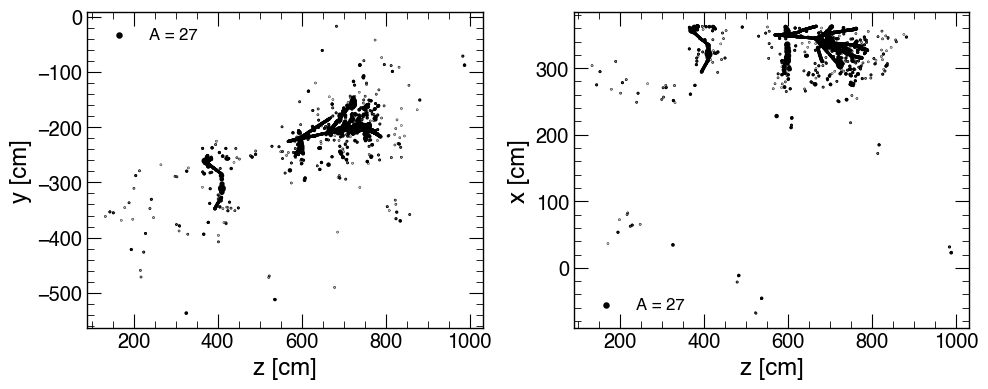

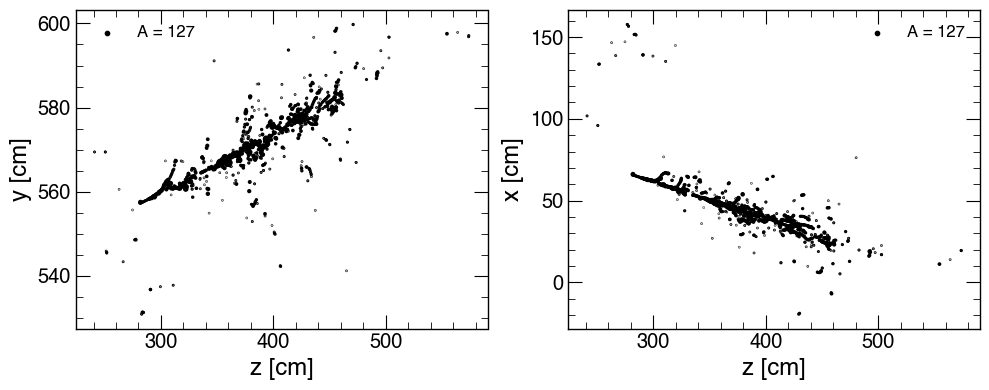

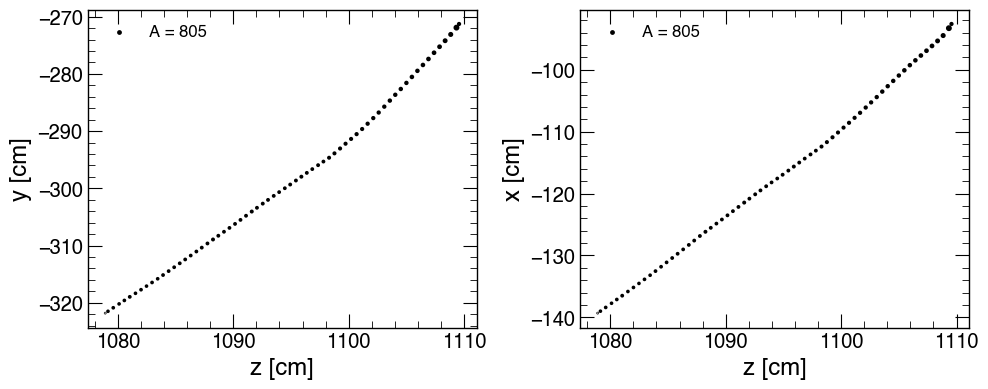

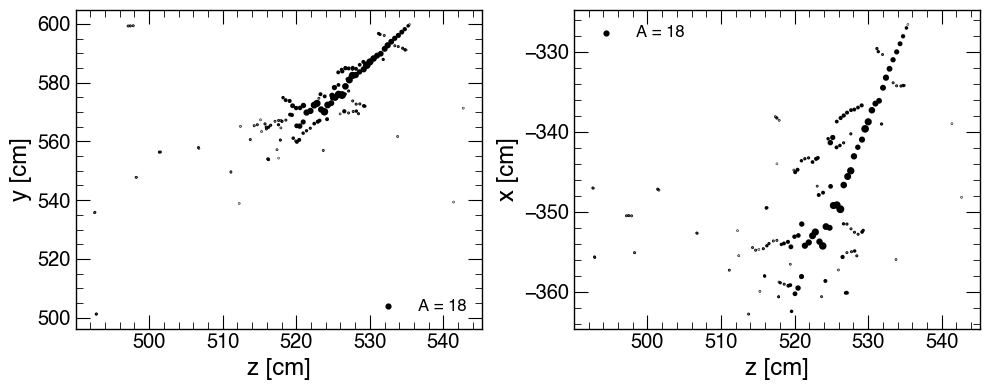

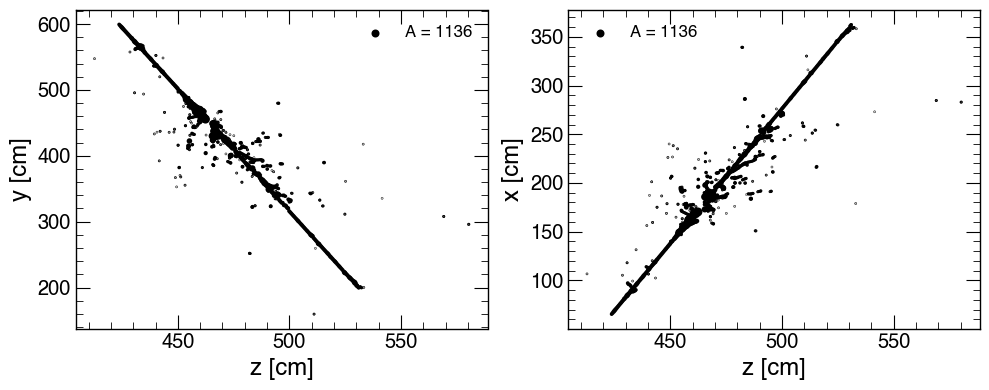

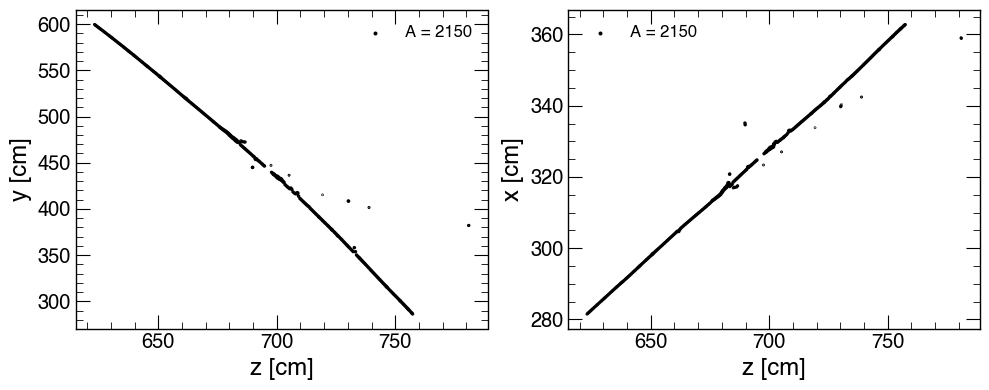

In [7]:
def plot_event_3d(df,ev):
    x= df[(df.event_uid==ev) & (df.bt_edep>0)]
    fig,ax = plt.subplots(1,2,figsize=(10,4))
    ax[0].scatter(x.bt_z, x.bt_y,s=x.adc_integral/10000, label = f'A = {int(get_anisotropy_3d(x))}')
    ax[1].scatter(x.bt_z, x.bt_x,s=x.adc_integral/10000, label = f'A = {int(get_anisotropy_3d(x))}')

    for i in [0,1]:
        ax[i].legend()
        ax[i].set_xlabel("z [cm]")
    ax[0].set_ylabel("y [cm]")
    ax[1].set_ylabel("x [cm]")
    plt.tight_layout()
    plt.show()



#beam 
plot_event_3d(nutps, beam_anisotropy_scores_3d[beam_anisotropy_scores_3d.between(10,50) ].index[4])
plot_event_3d(nutps, beam_anisotropy_scores_3d[beam_anisotropy_scores_3d.between(100,500) ].index[6])
plot_event_3d(nutps, beam_anisotropy_scores_3d[beam_anisotropy_scores_3d.between(700,900) ].index[2])


#cosmic
plot_event_3d(tps, cosmic_anisotropy_scores_3d[cosmic_anisotropy_scores_3d.between(10,20) ].index[0])
plot_event_3d(tps, cosmic_anisotropy_scores_3d[cosmic_anisotropy_scores_3d.between(1000,2000) ].index[7])
plot_event_3d(tps, cosmic_anisotropy_scores_3d[cosmic_anisotropy_scores_3d.between(2000,3000) ].index[7])

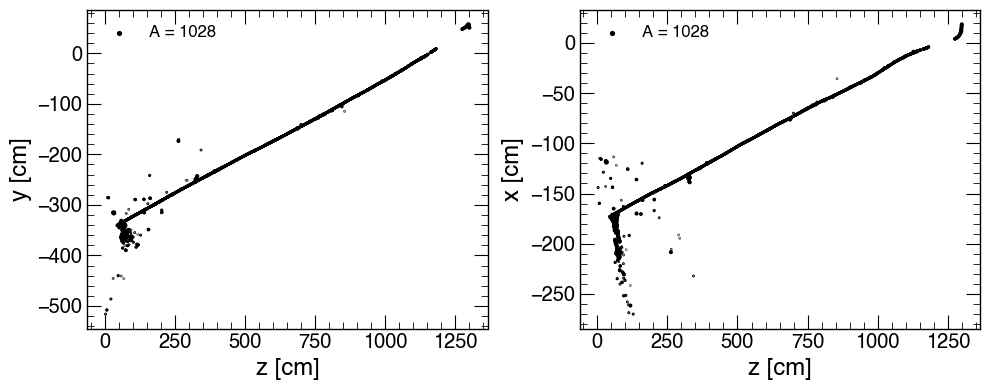

In [45]:
plot_event_3d(numutps, beamnumu_anisotropy_scores_3d[beamnumu_anisotropy_scores_3d.between(1000,1200) ].index[5])

# boundary score

In [ ]:
# Detector bounds
BOUNDS = {
    'x': (-360, 360),
    'y': (-600, 600),
    'z': (0, 1392),
}

def near_walls(p, tau=20.0, bounds=BOUNDS):
    """Return set of wall labels that point p is within tau of."""
    x, y, z = p
    walls = set()
    if x - bounds['x'][0] < tau: walls.add('x-')
    if bounds['x'][1] - x < tau: walls.add('x+')
    if y - bounds['y'][0] < tau: walls.add('y-')
    if bounds['y'][1] - y < tau: walls.add('y+')
    if z - bounds['z'][0] < tau: walls.add('z-')
    if bounds['z'][1] - z < tau: walls.add('z+')
    return walls

def get_boundary_score(df, tau=10.0, bounds=BOUNDS):
    df = df[df.bt_edep > 0]
    if len(df) < 20:
        return np.nan

    pts = np.column_stack([df.bt_x.values, df.bt_y.values, df.bt_z.values])
    w = df.bt_edep.values / df.bt_edep.sum()
    mu = np.average(pts, weights=w, axis=0)
    pts_c = pts - mu
    C = (pts_c * w[:, None]).T @ pts_c
    vals, vecs = np.linalg.eigh(C)
    u = vecs[:, np.argmax(vals)]

    s = pts_c @ u
    s01, s99 = np.percentile(s, [0.01, 99.9])
    p_min = mu + s01 * u
    p_max = mu + s99 * u

    w1 = near_walls(p_min, tau, bounds)
    w2 = near_walls(p_max, tau, bounds)

    end1_hits = len(w1) > 0
    end2_hits = len(w2) > 0
    walls_disjoint = w1.isdisjoint(w2)

    if end1_hits and end2_hits and walls_disjoint:
        return 2   # clean entry + exit through different walls
    elif end1_hits or end2_hits:
        return 1   # one end on a wall (stopping cosmic or corner case like yours)
    else:
        return 0


cosmic_boundary_scores = tps.groupby("event_uid").apply(get_boundary_score)
beam_boundary_scores = nutps.groupby("event_uid").apply(get_boundary_score)
beamnumu_boundary_scores = numutps.groupby("event_uid").apply(get_boundary_score)

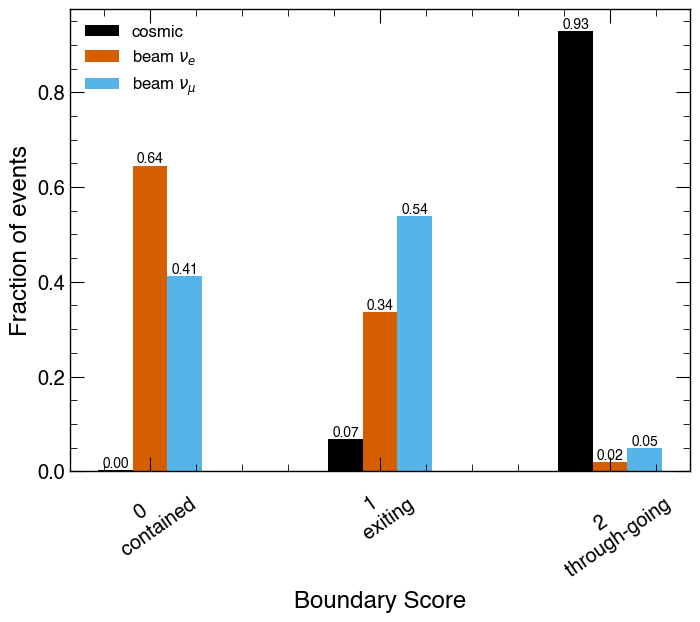

In [28]:
x = [0, 1, 2]
plt.figure(figsize=(8,6))
for scores, offset, label in [
    (cosmic_boundary_scores, -0.15, "cosmic"),
    (beam_boundary_scores, 0., r"beam $\nu_e$"),
    (beamnumu_boundary_scores, 0.15, r"beam $\nu_{\mu}$"),
    ]:
    scores = scores.dropna().astype(int)

    frac = np.bincount(scores, minlength=3)
    frac = frac / frac.sum()

    plt.bar(np.array(x) + offset, frac, width=0.15, label=label)

    for xi, yi in zip(np.array(x) + offset, frac):
        plt.text(xi, yi, f"{yi:.2f}", ha="center", va="bottom")

plt.xticks( x,["0 \n contained", "1 \n exiting", "2 \n through-going"], rotation =35)
plt.ylabel("Fraction of events")
plt.xlabel("Boundary Score")
plt.legend()
plt.show()

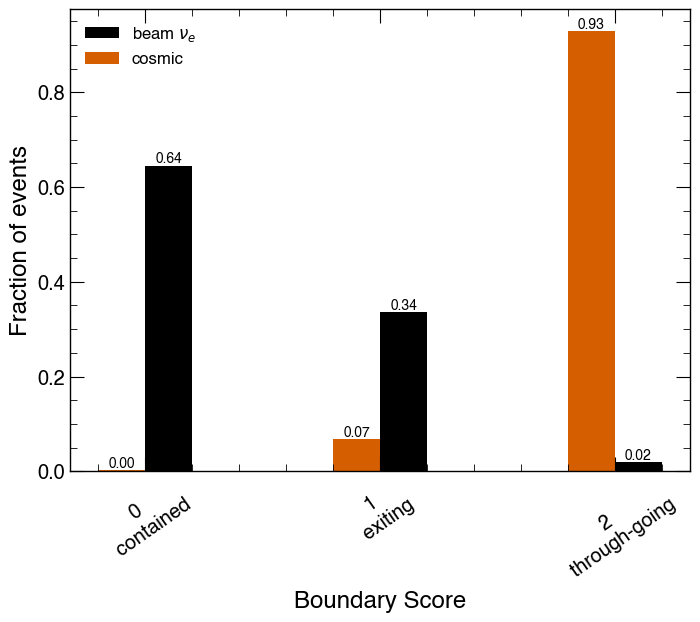

In [9]:
x = [0, 1, 2]
plt.figure(figsize=(8,6))
for scores, offset, label in [
    (beam_boundary_scores, 0.1, r"beam $\nu_e$"),
    (cosmic_boundary_scores, -0.1, "cosmic")]:
    scores = scores.dropna().astype(int)

    frac = np.bincount(scores, minlength=3)
    frac = frac / frac.sum()

    plt.bar(np.array(x) + offset, frac, width=0.2, label=label)

    for xi, yi in zip(np.array(x) + offset, frac):
        plt.text(xi, yi, f"{yi:.2f}", ha="center", va="bottom")

plt.xticks( x,["0 \n contained", "1 \n exiting", "2 \n through-going"], rotation =35)
plt.ylabel("Fraction of events")
plt.xlabel("Boundary Score")
plt.legend()
plt.show()

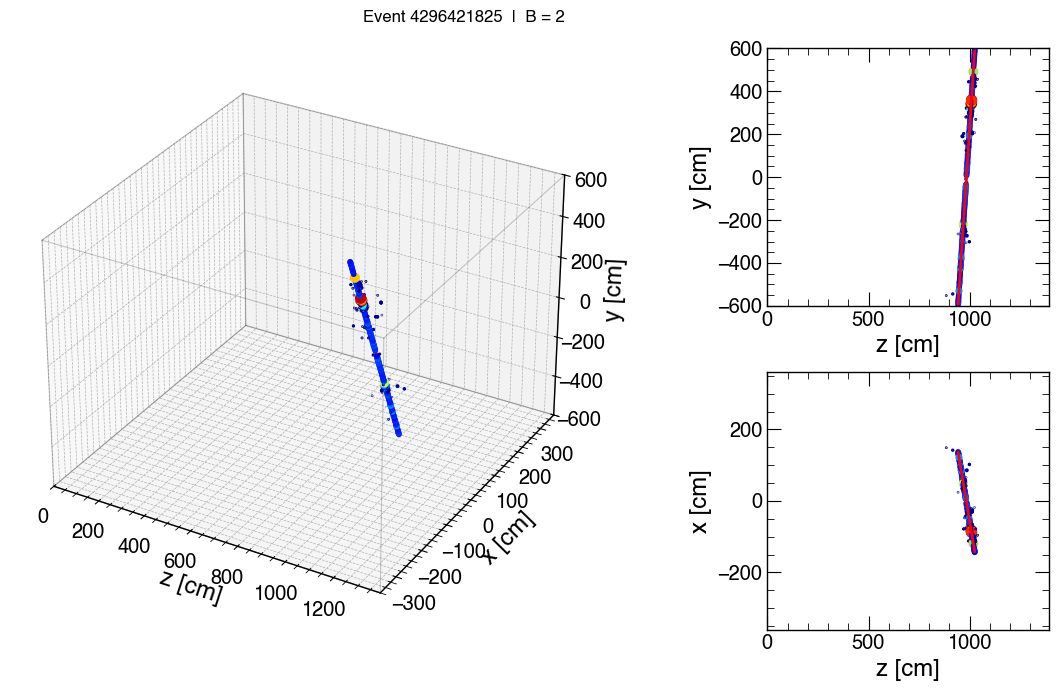

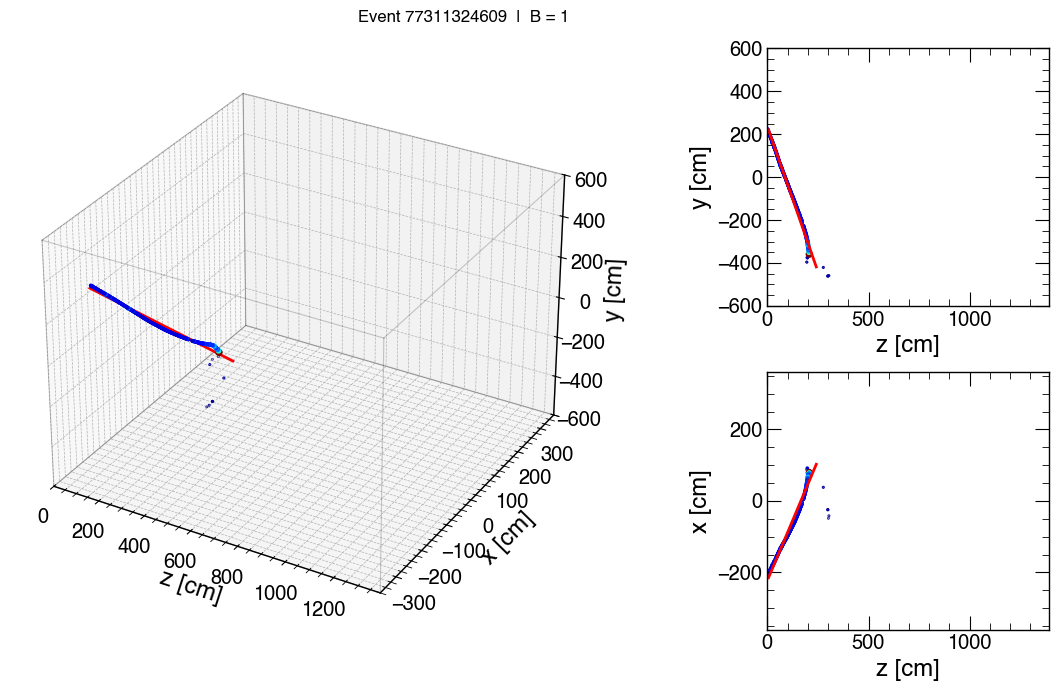

In [10]:
def plot_event_boundary_3d(df, ev):
    x = df[(df.event_uid == ev) & (df.bt_edep > 0)]
    if x.empty:
        return

    from itertools import combinations

    # Detector limits
    z_lim = (0, 1390)
    x_lim = (-360, 360)
    y_lim = (-600, 600)

    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, 1])

    ax3d = fig.add_subplot(gs[:, 0], projection="3d")
    ax_yz = fig.add_subplot(gs[0, 1])
    ax_xz = fig.add_subplot(gs[1, 1])

    s = x.adc_integral / 10000
    c = x.adc_integral

    ax3d.scatter( x.bt_z, x.bt_x, x.bt_y,s=s,c=c, cmap="jet", alpha=1)

    corners = np.array([[z, xi, y] for z in z_lim for xi in x_lim for y in y_lim])
    
    for i, j in combinations(range(8), 2):
        p1, p2 = corners[i], corners[j]
        if np.sum(p1 != p2) == 1:
            ax3d.plot(*zip(p1, p2), color="k", alpha=0.2, lw=0.8)

    # --- PCA axis ---
    pts = np.column_stack([x.bt_z, x.bt_x, x.bt_y])
    w = x.bt_edep.values / x.bt_edep.sum()
    mu = np.average(pts, weights=w, axis=0)

    pts_c = pts - mu
    C = (pts_c * w[:, None]).T @ pts_c
    vals, vecs = np.linalg.eigh(C)

    u = vecs[:, np.argmax(vals)]
    ss = pts_c @ u
    p1 = mu + np.percentile(ss, 0.25) * u
    p2 = mu + np.percentile(ss, 99.7) * u

    ax3d.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        "r-", lw=2,)

    ax_yz.scatter(x.bt_z, x.bt_y, s=s, c=c, cmap="jet")
    ax_yz.plot([p1[0], p2[0]], [p1[2], p2[2]], "r-", lw=2)

    ax_xz.scatter(x.bt_z, x.bt_x, s=s, c=c, cmap="jet")
    ax_xz.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", lw=2)

    ax3d.set( xlabel="z [cm]", ylabel="x [cm]", zlabel="y [cm]", xlim=z_lim, ylim=x_lim, zlim=y_lim,)

    ax_yz.set(xlabel="z [cm]", ylabel="y [cm]", xlim=z_lim, ylim=y_lim)
    ax_xz.set(xlabel="z [cm]", ylabel="x [cm]", xlim=z_lim, ylim=x_lim)

    B = get_boundary_score(x)
    fig.suptitle(f"Event {ev}  |  B = {int(B)}")

    plt.tight_layout()
    plt.show()


plot_event_boundary_3d(tps, cosmic_boundary_scores[cosmic_boundary_scores==2].index[2])
plot_event_boundary_3d(tps, cosmic_boundary_scores[cosmic_boundary_scores==1].index[2])



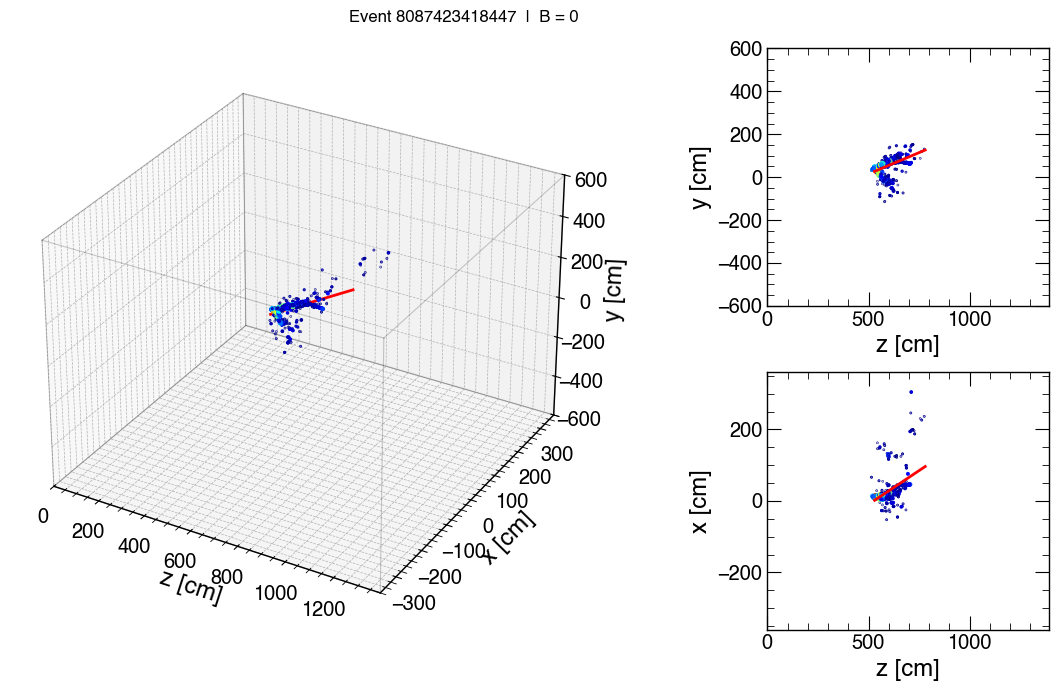

In [11]:
plot_event_boundary_3d(nutps, beam_boundary_scores[beam_boundary_scores==0].index[4])


# Combined Metric (A + B)

In [ ]:
beam_result = pd.concat([beam_boundary_scores.rename("b_score"),  beam_anisotropy_scores_3d.rename("a_score")],axis=1,)
display(beam_result)

cosmic_result =pd.concat([cosmic_boundary_scores.rename("b_score"),  cosmic_anisotropy_scores_3d.rename("a_score")],axis=1,)
display(cosmic_result)

beam_numu_result = pd.concat([beamnumu_boundary_scores.rename("b_score"),  beamnumu_anisotropy_scores_3d.rename("a_score")],axis=1,)
display(beam_numu_result)


,b_score,a_score
event_uid,,
8087423418439,0.0,131.946451
8087423418441,0.0,66.814265
8087423418442,2.0,12.084903
8087423418443,0.0,31.513424
8087423418444,1.0,8.737997
...,...,...
36627481171744,0.0,2.264250
36627481171745,1.0,5.345390
36627481171746,1.0,16.907687


,b_score,a_score
event_uid,,
4295242177,2.0,2195.299447
4295504321,1.0,84058.849443
4295766465,2.0,63022.897270
4295963073,NaN,NaN
4296421825,2.0,39288.068888
...,...,...
6489697235393,2.0,11330.079281
6764574159297,2.0,1913.108317
6764574224833,2.0,892.859095


,b_score,a_score
event_uid,,
8087423424458,2.0,3441.92038


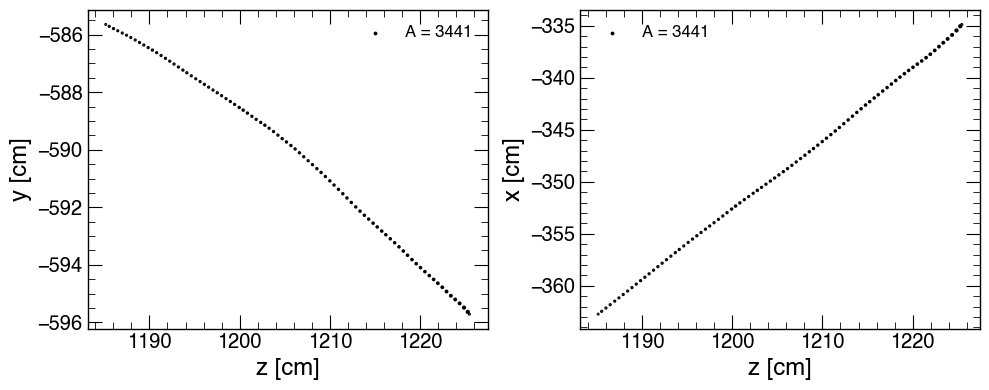

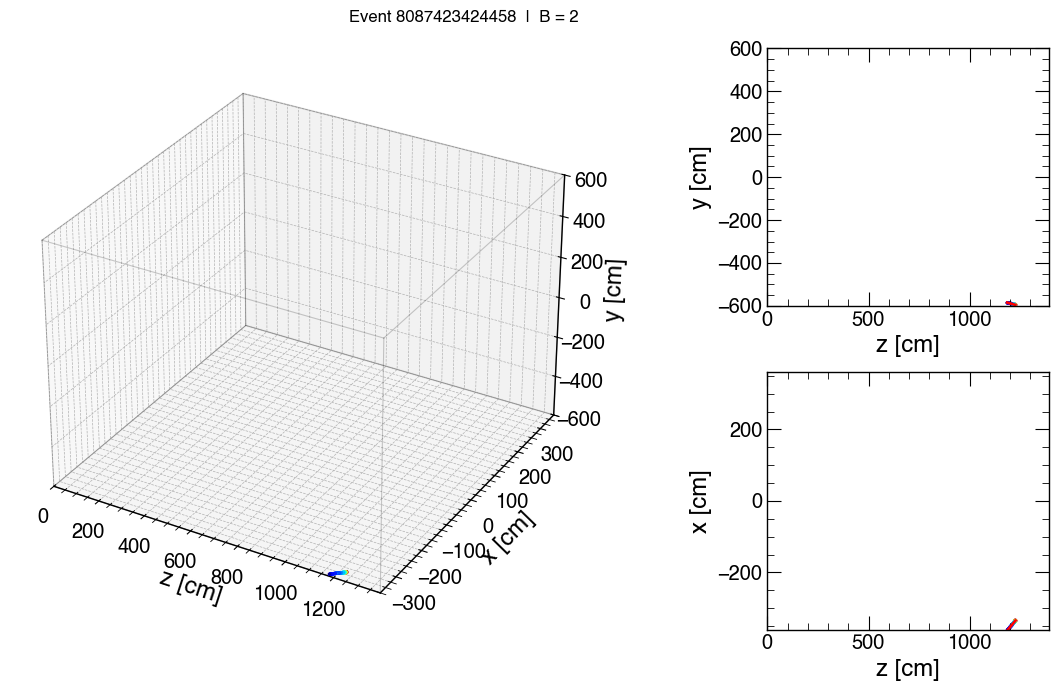

In [15]:
display(beam_result[(beam_result.b_score> 1 ) & (beam_result.a_score >1000)])

plot_event_3d(nutps, 8087423424458)
plot_event_boundary_3d(nutps, 8087423424458)

#plot_event_3d(nutps, 36627481154763)
#plot_event_boundary_3d(nutps, 36627481154763)

In [34]:
display(beam_numu_result[(beam_numu_result.b_score> 1 ) & (beam_numu_result.a_score >1000)])


,b_score,a_score
event_uid,,
36614596201364,2.0,12928.641104
36614596201512,2.0,7323.534608
36614596201885,2.0,1032.227428
36614596202387,2.0,1698.074483
36614596202646,2.0,1665.487761
...,...,...
36614596281270,2.0,8999.046482
36614596281389,2.0,1689.069702
36614596281527,2.0,3146.704965


In [ ]:
cosmic_result[(cosmic_result.b_score > 1) & (cosmic_result.a_score >1000)]

,b_score,a_score
event_uid,,
4295242177,2.0,2195.299447
4295766465,2.0,63022.897270
4296421825,2.0,39288.068888
8591520193,2.0,20316.027739
12884980161,2.0,43506.924357
...,...,...
6489696252353,2.0,16402.788408
6489697235393,2.0,11330.079281
6764574159297,2.0,1913.108317


In [48]:
A_score =5000
tagged_fraction_cosmic = len(cosmic_result[(cosmic_result.b_score==2 ) & (cosmic_result.a_score >A_score)])/ len(cosmic_result)
tagged_fraction_beam = len(beam_result[(beam_result.b_score ==2) & (beam_result.a_score >A_score)])/ len(beam_result)
taggaed_fraction_beammu = len(beam_numu_result[(beam_numu_result.b_score ==2) & (beam_numu_result.a_score >A_score)])/ len(beam_numu_result) 
print(tagged_fraction_cosmic*100, tagged_fraction_beam * 100, taggaed_fraction_beammu * 100)

66.31450629825274 0.0 0.4419513853476118


In [49]:
A_score =1000
tagged_fraction_cosmic = len(cosmic_result[(cosmic_result.b_score==2 ) & (cosmic_result.a_score >A_score)])/ len(cosmic_result)
tagged_fraction_beam = len(beam_result[(beam_result.b_score ==2) & (beam_result.a_score >A_score)])/ len(beam_result)
taggaed_fraction_beammu = len(beam_numu_result[(beam_numu_result.b_score ==2) & (beam_numu_result.a_score >A_score)])/ len(beam_numu_result) 
print(tagged_fraction_cosmic*100, tagged_fraction_beam * 100, taggaed_fraction_beammu * 100)

76.83868346200732 0.02574002574002574 1.3088560258371578


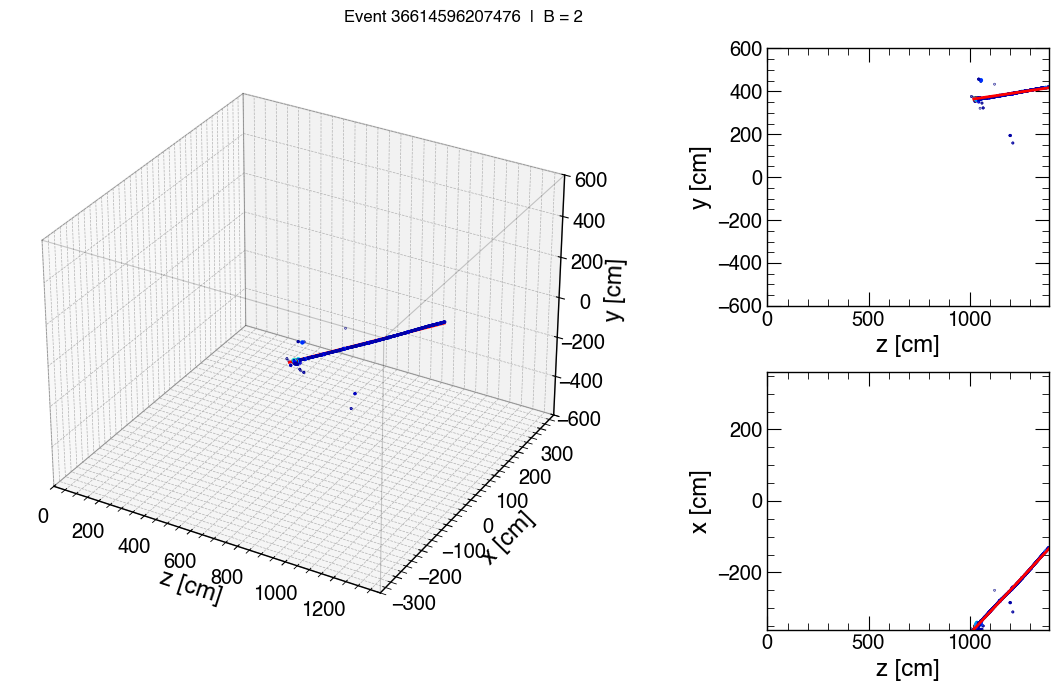

In [39]:
plot_event_boundary_3d(numutps, beam_numu_result[(beam_numu_result.b_score> 1 ) & (beam_numu_result.a_score >1000)].index[15])


# Verticality 

In [50]:
def get_verticality(df):
    df = df[df.bt_edep > 0]
    if len(df) < 20:
        return np.nan

    pts = np.column_stack([df.bt_x.values, df.bt_y.values, df.bt_z.values])
    w = df.bt_edep.values / df.bt_edep.sum()
    mu = np.average(pts, weights=w, axis=0)
    pts_c = pts - mu
    C = (pts_c * w[:, None]).T @ pts_c
    vals, vecs = np.linalg.eigh(C)
    u = vecs[:, np.argmax(vals)]  # principal axis unit vector (x, y, z)

    y_hat = np.array([0, 1, 0])
    return float(np.abs(u @ y_hat))  # = |u_y|, i.e. just the y-component

beam_verticality_scores= nutps.groupby("event_uid").apply(get_verticality)
beamnumu_verticality_scores= numutps.groupby("event_uid").apply(get_verticality)
cosmic_verticality_scores= tps.groupby("event_uid").apply(get_verticality)

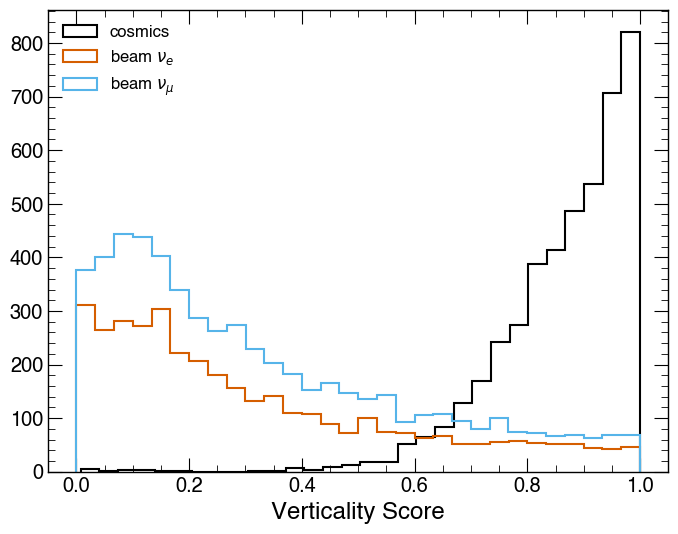

In [60]:
plt.figure(figsize=(8,6))
plt.hist(cosmic_verticality_scores, histtype='step', bins = 30, label = r'cosmics')
plt.hist(beam_verticality_scores, histtype='step', bins = 30, label = r'beam $\nu_e$')
plt.hist(beamnumu_verticality_scores, histtype='step', bins =30, label = r'beam $\nu_{\mu}$')
plt.legend()
plt.xlabel("Verticality Score")
plt.show()

# Combined Metric A & B & V

In [61]:
beam_result = pd.concat([
    beam_boundary_scores.rename("b_score"),
    beam_anisotropy_scores_3d.rename("a_score"),
    beam_verticality_scores.rename("v_score"),
], axis=1)

cosmic_result = pd.concat([
    cosmic_boundary_scores.rename("b_score"),
    cosmic_anisotropy_scores_3d.rename("a_score"),
    cosmic_verticality_scores.rename("v_score"),
], axis=1)

beam_numu_result = pd.concat([
    beamnumu_boundary_scores.rename("b_score"),
    beamnumu_anisotropy_scores_3d.rename("a_score"),
    beamnumu_verticality_scores.rename("v_score"),
], axis=1)

In [79]:
A_score =1000; V_score = 0.6; B_score = 2
tagged_fraction_cosmic = len(cosmic_result[(cosmic_result.b_score==B_score ) & (cosmic_result.a_score >A_score) & (cosmic_result.v_score>V_score)])/ len(cosmic_result)
tagged_fraction_beam = len(beam_result[(beam_result.b_score == B_score) & (beam_result.a_score >A_score)& (beam_result.v_score>V_score)])/ len(beam_result)
taggaed_fraction_beammu = len(beam_numu_result[(beam_numu_result.b_score ==B_score) & (beam_numu_result.a_score >A_score)& (beam_numu_result.v_score>V_score)])/ len(beam_numu_result) 
print(tagged_fraction_cosmic*100, tagged_fraction_beam * 100, taggaed_fraction_beammu * 100)

75.11174319382364 0.0 0.0


In [80]:
A_score =100; V_score = 0.6; B_score = 2
tagged_fraction_cosmic = len(cosmic_result[(cosmic_result.b_score==B_score ) & (cosmic_result.a_score >A_score) & (cosmic_result.v_score>V_score)])/ len(cosmic_result)
tagged_fraction_beam = len(beam_result[(beam_result.b_score == B_score) & (beam_result.a_score >A_score)& (beam_result.v_score>V_score)])/ len(beam_result)
taggaed_fraction_beammu = len(beam_numu_result[(beam_numu_result.b_score ==B_score) & (beam_numu_result.a_score >A_score)& (beam_numu_result.v_score>V_score)])/ len(beam_numu_result) 
print(tagged_fraction_cosmic*100, tagged_fraction_beam * 100, taggaed_fraction_beammu * 100)

80.33319788703778 0.0 0.0
